# NYC Property Sales — Exploratory Data Analysis
Dataset: `nyc-property-sales.csv` (located alongside this notebook).

## Phase 1 — Business Problem & Dataset Selection

### 1.1 Business Domain & Context

This project analyses the New York City residential and commercial property market using the Rolling Sales File maintained by the NYC Department of Finance. The market is large, fragmented, and politically sensitive — every parcel is recorded across 5 boroughs, 500+ neighborhoods, and ~150 building-class categories, and prices range from $0 family transfers to multi-hundred-million-dollar Manhattan deals.

**Business problem.** Understand the *price drivers, geographic concentration, and temporal trends* in NYC property sales so that real-estate investors can identify under- and over-valued segments, city planners and tax assessors can monitor market health, and brokers can benchmark transactions. The analysis below explores the data along these three axes and culminates in a simple regression model relating physical attributes (sq ft, units, year built, borough) to sale price.

### 1.2 Dataset

- **Source:** NYC Department of Finance — *Rolling Sales File* (compiled from city property-tax records).
- **Format:** CSV, single flat file (`nyc-property-sales.csv`).
- **Records:** 2,018,049 rows.
- **Attributes:** 21 columns — Borough-Block-Lot identifiers, location, building classification, unit counts, square footage, year built, sale price, sale date.
- **Time span:** 2004 – 2023 (per `SALE DATE`).

### 1.3 Data Dictionary

| Field | Type | Description | Notes |
|---|---|---|---|
| `BOROUGH` | categorical (1–5) | Borough the property is in | 1 = Manhattan, 2 = Bronx, 3 = Brooklyn, 4 = Queens, 5 = Staten Island |
| `NEIGHBORHOOD` | string | Assessor-assigned neighborhood name | ~517 unique values |
| `BUILDING CLASS CATEGORY` | string | Broad-usage grouping of building classes (e.g. *01 ONE FAMILY HOMES*) | The file is sorted by Borough → Neighborhood → Building Class Category → Block → Lot |
| `TAX CLASS AT PRESENT` | categorical | Tax class based on the property's use | **Class 1** — ≤3-unit residential (one-/two-/three-family homes, small stores/offices with 1–2 attached apartments), residential-zoned vacant land, condos ≤3 stories. **Class 2** — all other primarily-residential property (coops, larger condos). **Class 3** — utility property (equipment owned by a gas, telephone or electric company). **Class 4** — everything else (offices, factories, warehouses, garages, etc.) |
| `BLOCK` | int | Tax Block — a borough sub-division on which real properties are located | Combined with Borough and Lot it uniquely identifies a parcel; not affected by street-entrance changes |
| `LOT` | int | Tax Lot — sub-division of a tax block representing the property's unique location | Distinguishes individual units inside a building (e.g. each condo) |
| `EASE-MENT` | string | A right (e.g. right of way) allowing another entity limited use of the property | Example: MTA railroad tracks running across a parcel. Mostly null |
| `BUILDING CLASS AT PRESENT` | string | 2-character building code describing constructive use | First char = general class (A = one-family home, O = office, R = condo). Second char = subtype (A0 = Cape Cod style one-family, O4 = tower-type office, R5 = commercial condo). Interchangeable with the Dept. of Buildings "Building Code" |
| `ADDRESS` | string | Street address of the property | Coop sales include the apartment number in this field |
| `APARTMENT NUMBER` | string | Unit number | Often null for non-coop sales |
| `ZIP CODE` | int | Postal code | |
| `RESIDENTIAL UNITS` | int | Number of residential units at the property | |
| `COMMERCIAL UNITS` | int | Number of commercial units at the property | |
| `TOTAL UNITS` | int | Total units at the property | Should equal residential + commercial |
| `LAND SQUARE FEET` | int | Land area of the property in square feet | |
| `GROSS SQUARE FEET` | int | Total floor area of the building, measured from the exterior walls, including land area and the space within any structure on the property | |
| `YEAR BUILT` | int | Year the structure was built | `0` is used as a sentinel for "unknown" |
| `TAX CLASS AT TIME OF SALE` | categorical | Tax class at the date of sale | Same 1–4 scheme as `TAX CLASS AT PRESENT` |
| `BUILDING CLASS AT TIME OF SALE` | string | Building class code at the date of sale | Same letter-number scheme |
| `SALE PRICE` | int | Price paid for the property | **A `$0` sale indicates a transfer of ownership without cash consideration** — e.g. a parent transferring property to a child. Treated as a non-arm's-length record in this analysis |
| `SALE DATE` | datetime | Date the property sold | |

### 1.4 Business Questions (Q1–Q7)

**Main Questions**

- **Q1 — Descriptive Statistics.** How are NYC property sales distributed across the key numeric variables (sale price, gross sq ft, land sq ft, year built, total units), and what do their central tendency, spread, and shape reveal about the market?
- **Q2 — Trend Analysis.** How has the NYC property market evolved from 2004–2023 in terms of transaction volume and median sale price, and are there visible cyclical effects from the 2008 financial crisis or the 2020 pandemic?
- **Q3 — Cross-Tabulation.** How does median sale price vary across the interaction of Borough × Building Class Category, and which borough–property-type combinations are the most premium and most affordable?
- **Q4 — Drill-Down.** Where is NYC sales value concentrated when you drill from city-wide totals down to borough → neighborhood → building class?
- **Q5 — Correlation & Predictive.** Which numeric attributes correlate most strongly with sale price, and how well can a linear regression on the top predictors explain price variation?

**Ad Hoc Questions**

- **Ad Hoc Q6 (from Q5).** The correlation heatmap shows `LAND SQUARE FEET` and `GROSS SQUARE FEET` are collinear but only weakly tied to price — is that because the many `0`-valued square footage rows are dragging the relationship down? How does the correlation change when those rows are excluded?
- **Ad Hoc Q7 (from Q2).** If the yearly time series reveals a sharp drop in transaction volume around 2009, was the decline uniform across all 5 boroughs, or did Manhattan / luxury segments recover faster than the outer boroughs?

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_theme(style='whitegrid', context='notebook', palette='rocket')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 110,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlepad': 10,
    'figure.autolayout': True,
})

In [33]:
from pathlib import Path

CSV_PATH = Path('nyc-property-sales.csv')
data = pd.read_csv(CSV_PATH, low_memory=False)
data.head()

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,1,ALPHABET CITY,01 ONE FAMILY DWELLINGS,1,374,46,NaN,A4,347 EAST 4TH STREET,NaN,10009.0,1.0,0.0,1.0,2116.0,4400.0,1900.0,1,A4,399000,2022-09-29 00:00:00
1,1,ALPHABET CITY,02 TWO FAMILY DWELLINGS,1,377,1,NaN,S2,110 AVENUE C,NaN,10009.0,2.0,1.0,3.0,1502.0,2790.0,1901.0,1,S2,2999999,2022-09-15 00:00:00
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,373,16,NaN,C1,326 EAST 4TH STREET,NaN,10009.0,10.0,0.0,10.0,2204.0,8625.0,1899.0,2,C1,16800000,2022-08-04 00:00:00
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,373,17,NaN,C1,328 EAST 4TH STREET,NaN,10009.0,10.0,0.0,10.0,2204.0,8625.0,1900.0,2,C1,16800000,2022-08-04 00:00:00
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,376,54,NaN,C4,"719 EAST SIXTH STREET, 1B",NaN,10009.0,20.0,0.0,20.0,2302.0,9750.0,1900.0,2,C4,158822,2022-09-27 00:00:00


## Phase 2 — Data Profiling & Exploratory Data Analysis

The cells below profile the raw data (shape, dtypes, missing, duplicates, descriptive stats), then apply cleaning, run an IQR-based outlier scan, visualise distributions, examine correlations, and close with a short summary of key observations.

#### 2.1 How big is the data?

In [20]:
data.shape

(2018049, 21)

#### 2.2 How does the data look?

In [21]:
data.sample(5)

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
991624,3,SHEEPSHEAD BAY,10 COOPS - ELEVATOR APARTMENTS,2,7441,263,,D4,"2909 OCEAN AVE, 4H",,11235.0,0.0,0.0,0.0,0.0,0.0,1957.0,2,D4,58000,2011-09-16 00:00:00
569085,4,ARVERNE,02 TWO FAMILY DWELLINGS,1,16058,35,,B2,72-52 ALMEDA AVENUE,,11692.0,2.0,0.0,2.0,3000.0,2001.0,1999.0,1,B2,273000,2016-07-29 00:00:00
399466,4,FLORAL PARK,01 ONE FAMILY DWELLINGS,1,8712,18,NaN,A1,80-27 256TH STREET,NaN,11004.0,1.0,0.0,1.0,4000.0,1825.0,1950.0,1,A1,90000,2018-09-12 00:00:00
460650,3,BUSHWICK,03 THREE FAMILY DWELLINGS,1,3335,11,,C0,266 LINDEN STREET,,11237.0,3.0,0.0,3.0,1341.0,3000.0,1931.0,1,C0,0,2017-12-01 00:00:00
1438447,4,HAMMELS,05 TAX CLASS 1 VACANT LAND,2,16139,11,,C1,123 BEACH 93 STREET,,11693.0,78.0,0.0,78.0,18487.0,67500.0,2007.0,1,V0,2437000,2006-05-31 00:00:00


#### 2.3 What are the data types?

In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2018049 entries, 0 to 2018048
Data columns (total 21 columns):
 #   Column                          Dtype 
---  ------                          ----- 
 0   BOROUGH                         object
 1   NEIGHBORHOOD                    str   
 2   BUILDING CLASS CATEGORY         str   
 3   TAX CLASS AT PRESENT            str   
 4   BLOCK                           object
 5   LOT                             object
 6   EASE-MENT                       str   
 7   BUILDING CLASS AT PRESENT       str   
 8   ADDRESS                         str   
 9   APARTMENT NUMBER                str   
 10   ZIP CODE                       object
 11  RESIDENTIAL UNITS               object
 12  COMMERCIAL UNITS                object
 13  TOTAL UNITS                     object
 14  LAND SQUARE FEET                object
 15  GROSS SQUARE FEET               object
 16  YEAR BUILT                      object
 17  TAX CLASS AT TIME OF SALE       object
 18  BUILDING CLAS

#### 2.4 Missing values — counts

In [23]:
data.isnull().sum()

BOROUGH                                0
NEIGHBORHOOD                           0
BUILDING CLASS CATEGORY                0
TAX CLASS AT PRESENT                 838
BLOCK                                  0
LOT                                    0
EASE-MENT                         613648
BUILDING CLASS AT PRESENT            838
ADDRESS                                0
APARTMENT NUMBER                  470673
 ZIP CODE                             47
RESIDENTIAL UNITS                 120893
COMMERCIAL UNITS                  190743
TOTAL UNITS                       109684
LAND SQUARE FEET                  201953
GROSS SQUARE FEET                 201952
YEAR BUILT                         36651
TAX CLASS AT TIME OF SALE              0
BUILDING CLASS AT TIME OF SALE         0
SALE PRICE                             0
SALE DATE                              0
dtype: int64

#### 2.5 Descriptive statistics

In [24]:
data.describe()

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
count,2018049,2018049,2018049,2017211,2018049,2018049,1404401,2017211,2018049,1547376,2018002.0,1897156.0,1827306.0,1908365.0,1816096.0,1816097.0,1981398.0,2018049,2018049,2018049,2018049
unique,10,517,146,14,19949,8082,3,217,1268223,31624,370.0,674.0,257.0,717.0,24906.0,28481.0,502.0,8,216,114422,7638
top,4,MIDTOWN WEST,01 ONE FAMILY HOMES,1,1027,1,,D4,870 7 AVENUE,,10019.0,1.0,0.0,1.0,0.0,0.0,0.0,1,D4,0,2023-03-31 00:00:00
freq,616579,51353,207612,928263,17948,91393,1404387,296254,13510,1031043,57070.0,776581.0,1626703.0,877413.0,645491.0,685074.0,171899.0,986901,296527,591822,1958


#### 2.6 Duplicate values

In [25]:
data.duplicated().sum()

np.int64(73451)

#### 2.7 Missing-value & duplicate treatment

Actions and their rationale:

| Action | Rationale |
|---|---|
| Drop `EASE-MENT` column | ≈70% missing; sparse right-of-way code with no analytical value here |
| Drop 73,451 exact duplicate rows | Same record appears multiple times — almost certainly data-entry artefacts |
| Coerce numeric columns with `pd.to_numeric(..., errors='coerce')` | Columns load as `object` because of mixed/blank values; coercing yields true numerics for stats and plots |
| Parse `SALE DATE` to datetime | Required for the Q2 time-series analysis |
| Replace `0` in `YEAR BUILT`, `LAND SQUARE FEET`, `GROSS SQUARE FEET` with `NaN` | These are sentinel placeholders, not real measurements — a building cannot be 0 sq ft |
| Add `is_arms_length = SALE PRICE > 10000` flag (do **not** drop) | A `$0` sale is a transfer of ownership without cash consideration (e.g. parent → child), not a data error. The records are retained for Ad Hoc Q6 / borough-segment work; downstream price analysis filters with this boolean |

In [27]:
before_rows = len(data)

if 'EASE-MENT' in data.columns:
    data = data.drop(columns=['EASE-MENT'])

data = data.drop_duplicates().reset_index(drop=True)

numeric_candidates = [
    'BOROUGH', 'BLOCK', 'LOT', ' ZIP CODE',
    'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
    'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
    'TAX CLASS AT TIME OF SALE', 'SALE PRICE',
]
for col in numeric_candidates:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

if 'SALE DATE' in data.columns:
    data['SALE DATE'] = pd.to_datetime(data['SALE DATE'], errors='coerce')

for col in ['YEAR BUILT', 'LAND SQUARE FEET', 'GROSS SQUARE FEET']:
    if col in data.columns:
        data.loc[data[col] == 0, col] = np.nan

data['is_arms_length'] = data['SALE PRICE'] > 10000

print(f"Rows before cleaning : {before_rows:,}")
print(f"Rows after cleaning  : {len(data):,}  (dropped {before_rows - len(data):,} duplicates)")
print(f"Arms-length sales    : {data['is_arms_length'].sum():,}  ({data['is_arms_length'].mean()*100:.1f}%)")
print()
print("Top 10 columns by missing-value count after cleaning:")
data.isnull().sum().sort_values(ascending=False).head(10)

Rows before cleaning : 2,018,049
Rows after cleaning  : 1,944,598  (dropped 73,451 duplicates)
Arms-length sales    : 1,333,105  (68.6%)

Top 10 columns by missing-value count after cleaning:


GROSS SQUARE FEET            852715
LAND SQUARE FEET             814224
APARTMENT NUMBER             414668
YEAR BUILT                   203683
COMMERCIAL UNITS             159840
RESIDENTIAL UNITS            103000
TOTAL UNITS                   94098
TAX CLASS AT PRESENT            773
BUILDING CLASS AT PRESENT       773
 ZIP CODE                        44
dtype: int64

#### 2.8 Outlier detection (IQR)

For each numeric column we compute the inter-quartile range and flag values outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` as outliers. Sale-price outliers are computed on the **arms-length subset** so the $0 transfers don't dominate the lower tail.

In [28]:
def iqr_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (s < lo) | (s > hi)
    return {
        'q1': q1, 'q3': q3, 'iqr': iqr,
        'lower_bound': lo, 'upper_bound': hi,
        'n_outliers': int(mask.sum()),
        'pct_outliers': round(100 * mask.mean(), 2),
    }

cols_to_check = ['SALE PRICE', 'GROSS SQUARE FEET', 'LAND SQUARE FEET', 'TOTAL UNITS', 'YEAR BUILT']
rows = []
for col in cols_to_check:
    if col in data.columns:
        s = data.loc[data['is_arms_length'], col] if col == 'SALE PRICE' else data[col]
        rows.append({'column': col, **iqr_outliers(s)})

outlier_summary = pd.DataFrame(rows).set_index('column')
outlier_summary

,q1,q3,iqr,lower_bound,upper_bound,n_outliers,pct_outliers
column,,,,,,,
SALE PRICE,325000.0,909500.0,584500.0,-551750.0,1786250.0,143495,10.76
GROSS SQUARE FEET,1500.0,3102.0,1602.0,-903.0,5505.0,99345,9.10
LAND SQUARE FEET,2000.0,4000.0,2000.0,-1000.0,7000.0,86853,7.68
TOTAL UNITS,1.0,2.0,1.0,-0.5,3.5,126081,6.81
YEAR BUILT,1925.0,1970.0,45.0,1857.5,2037.5,1786,0.10


#### 2.9 Distributions & correlation (cleaned data)

With numerics coerced and cleaning applied, run histograms, boxplots, and a correlation heatmap on the cleaned numeric frame.

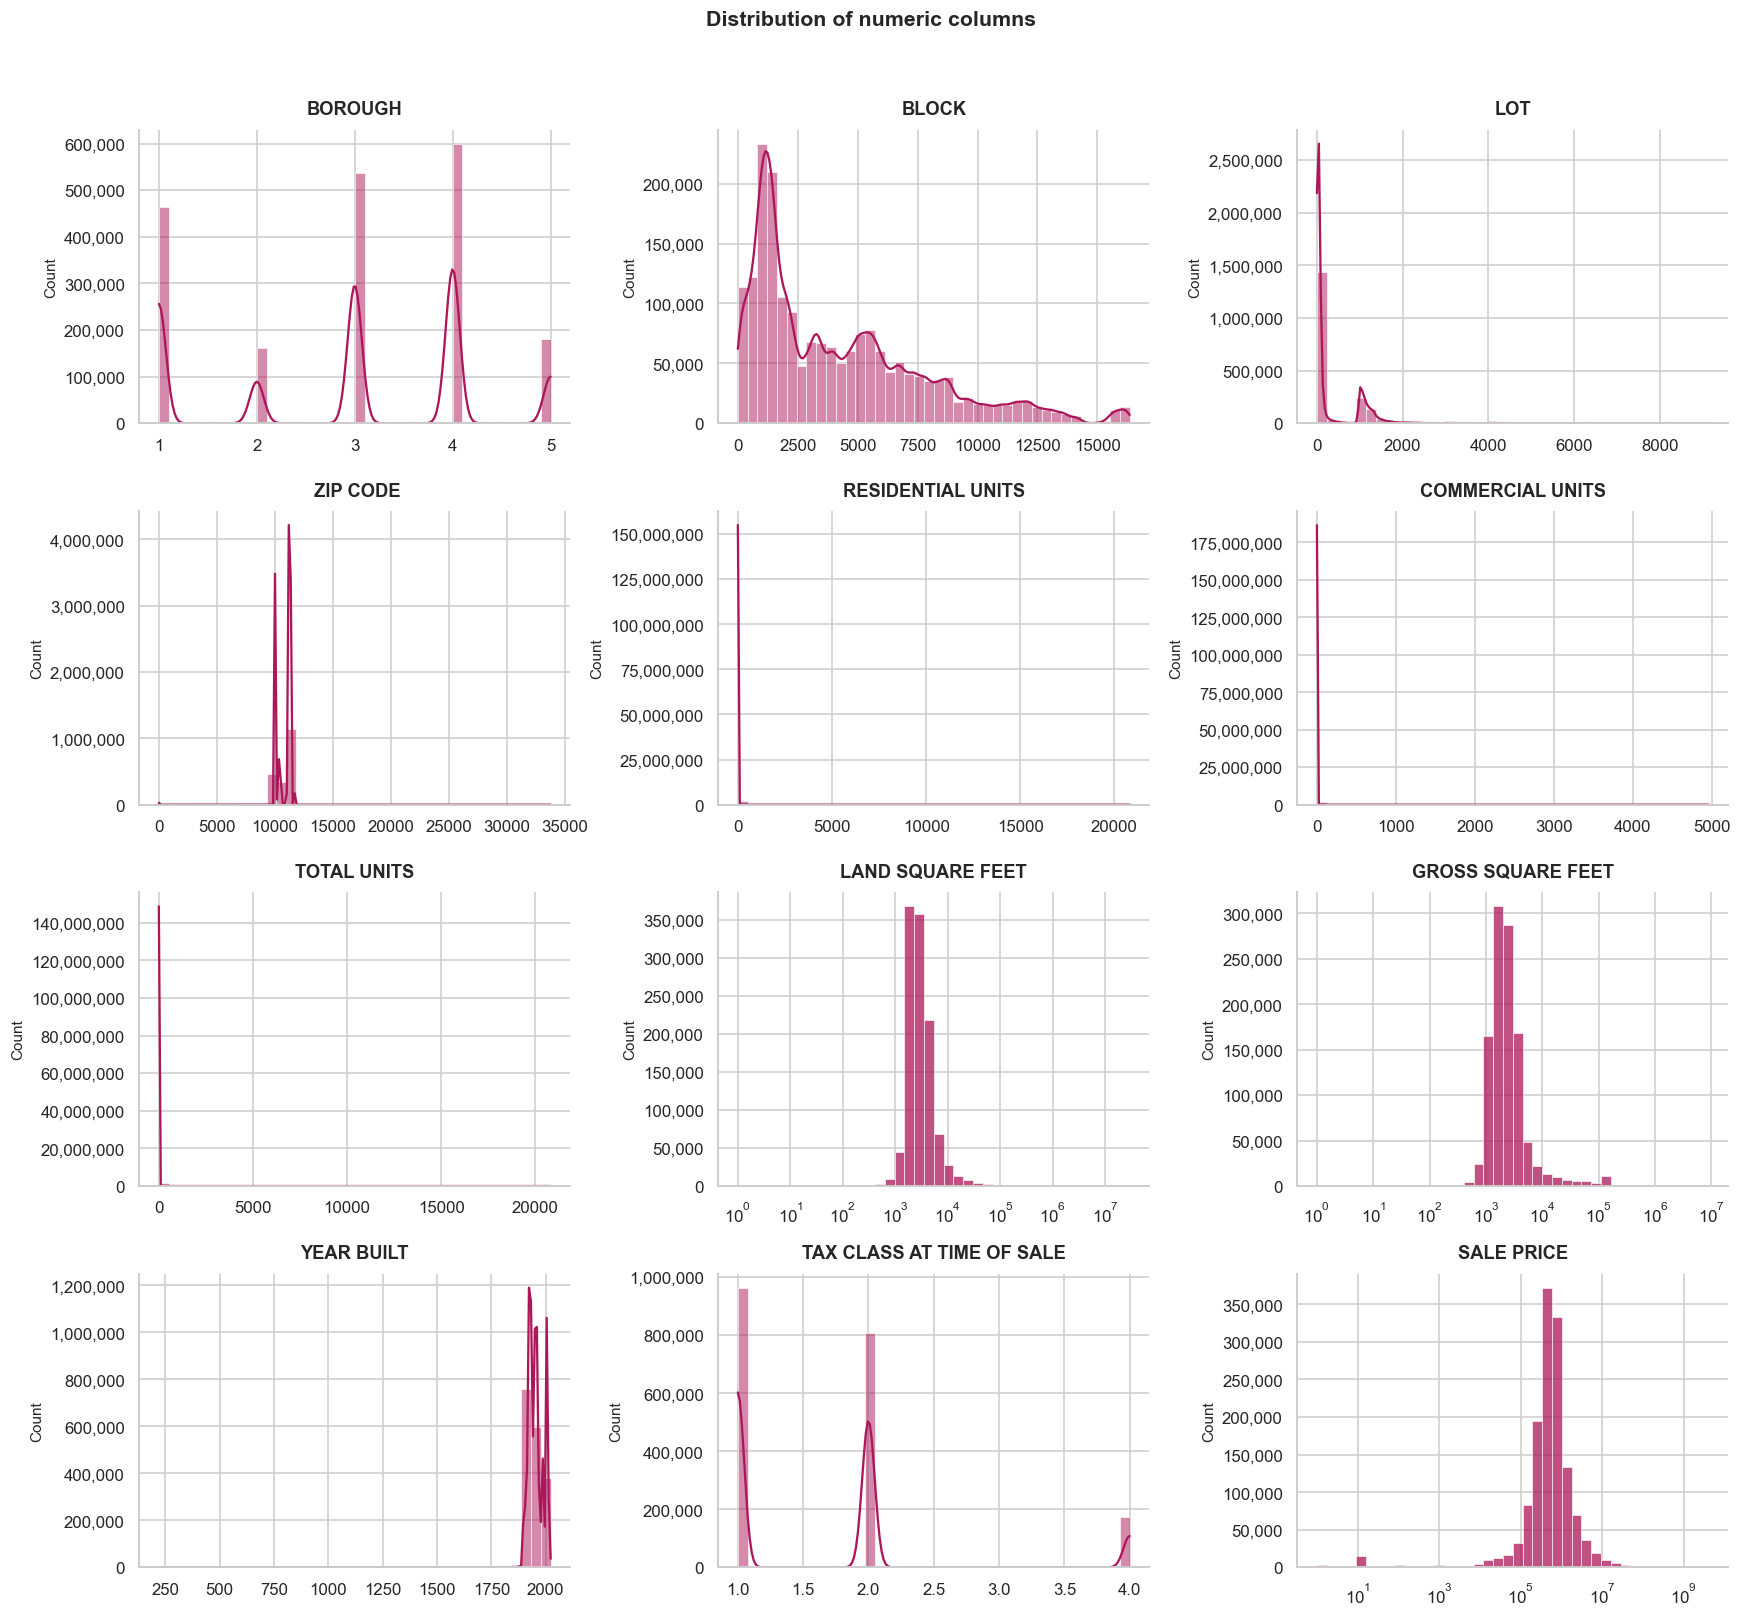

In [29]:
numeric_df = data.select_dtypes(include=np.number).drop(columns=['is_arms_length'], errors='ignore')
log_cols = {'SALE PRICE', 'GROSS SQUARE FEET', 'LAND SQUARE FEET'}

cols = list(numeric_df.columns)
ncols = 3
nrows = (len(cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.6 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, cols):
    series = numeric_df[col].dropna()
    if col in log_cols:
        series = series[series > 0]
        sns.histplot(series, bins=40, ax=ax, log_scale=(True, False),
                     color=sns.color_palette('rocket', 6)[2], edgecolor='white', linewidth=0.4)
    else:
        sns.histplot(series, bins=40, ax=ax, kde=True,
                     color=sns.color_palette('rocket', 6)[2], edgecolor='white', linewidth=0.4)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for ax in axes[len(cols):]:
    ax.set_visible(False)

fig.suptitle('Distribution of numeric columns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

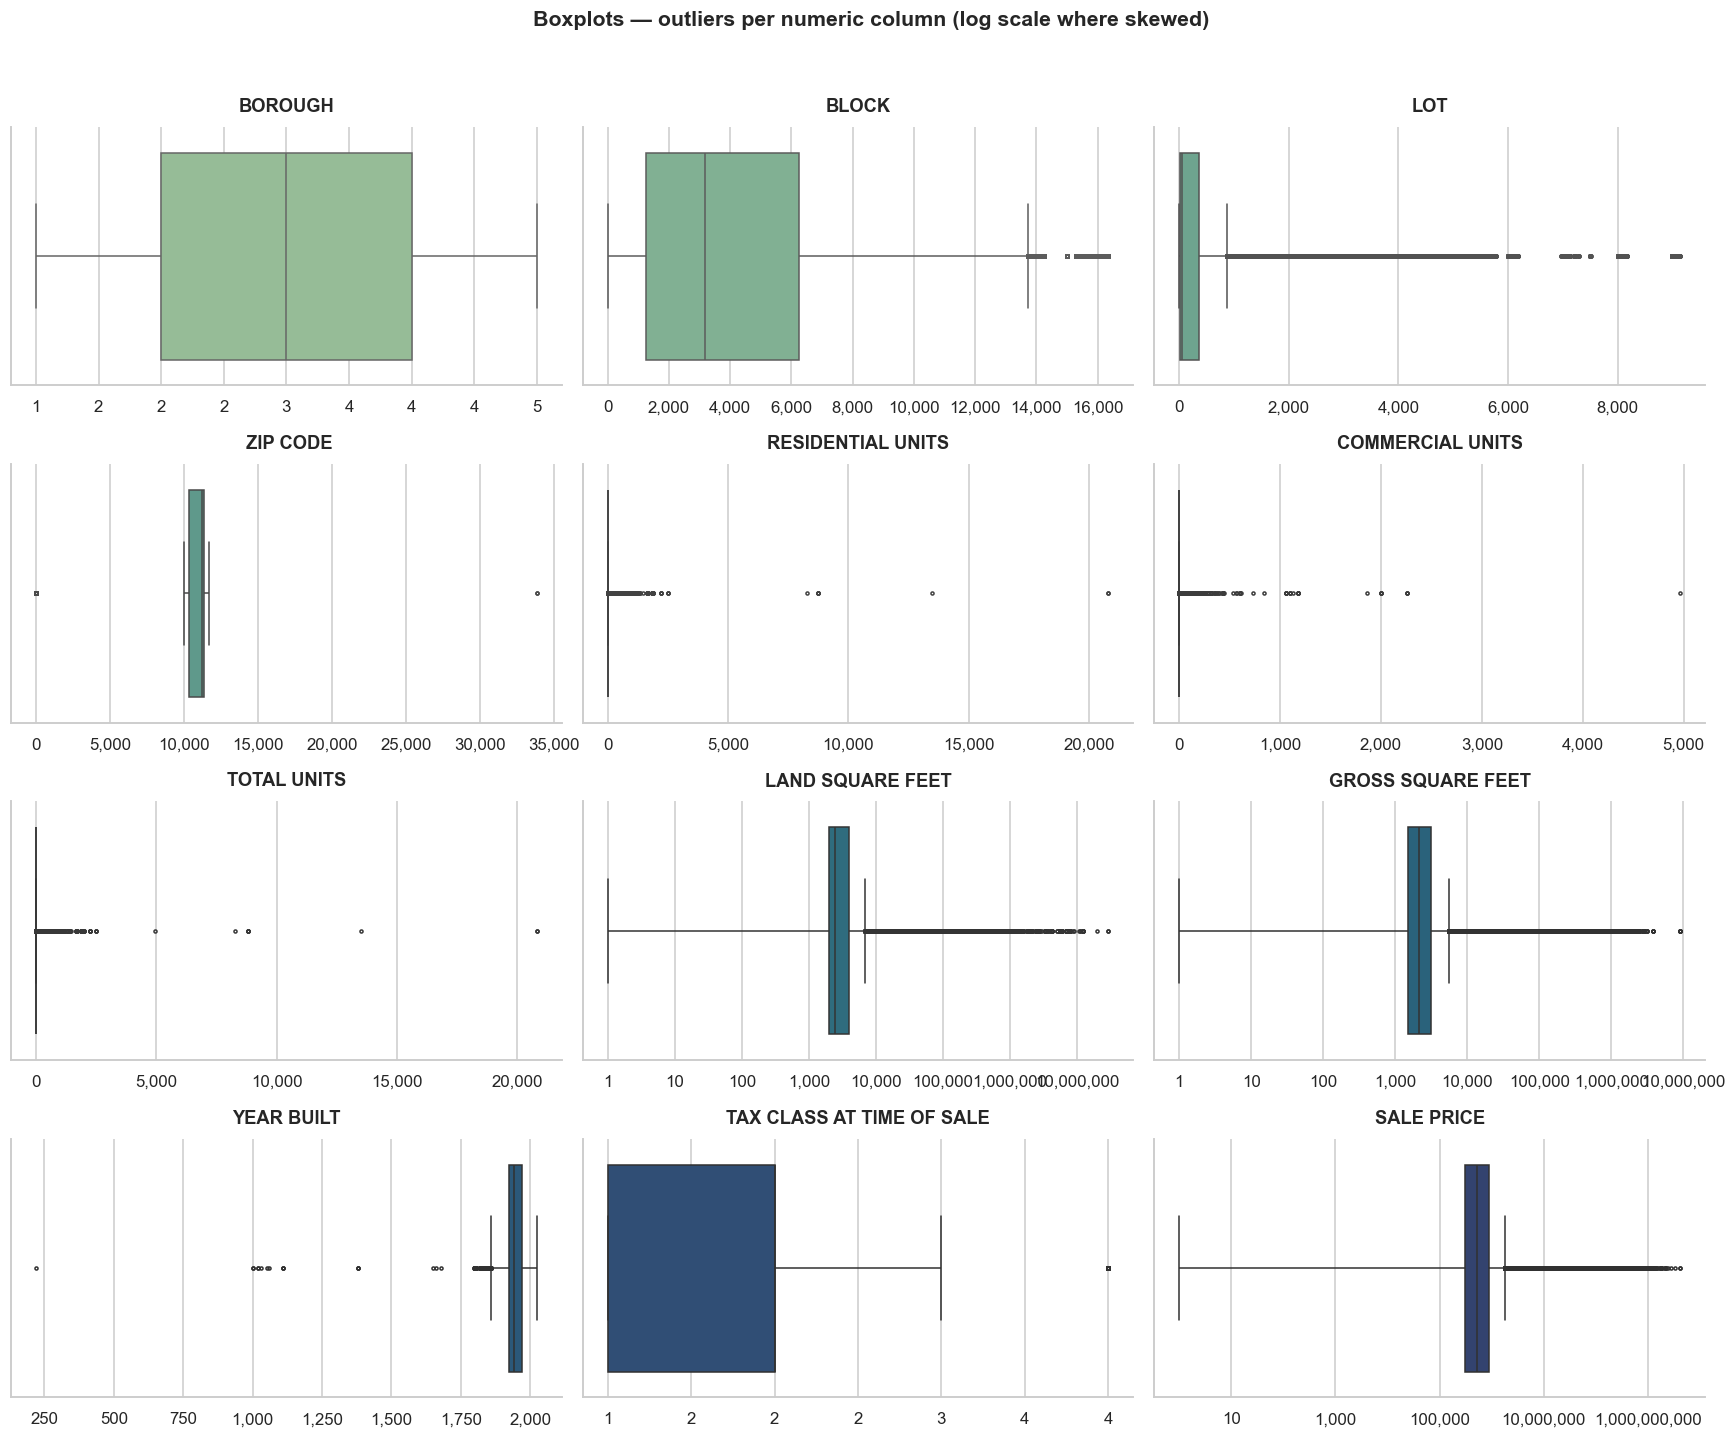

In [30]:
numeric_df = data.select_dtypes(include=np.number).drop(columns=['is_arms_length'], errors='ignore')
log_cols = {'SALE PRICE', 'GROSS SQUARE FEET', 'LAND SQUARE FEET'}

cols = list(numeric_df.columns)
ncols = 3
nrows = max(1, (len(cols) + ncols - 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).flatten()

palette = sns.color_palette('crest', len(cols))

for ax, col, color in zip(axes, cols, palette):
    series = numeric_df[col].dropna()
    if col in log_cols:
        series = series[series > 0]
    sns.boxplot(x=series, ax=ax, color=color, fliersize=2, linewidth=1.0)
    ax.set_title(col)
    ax.set_xlabel('')
    if col in log_cols:
        ax.set_xscale('log')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x:,.0f}' if abs(x) >= 1 else f'{x:g}'))

for ax in axes[len(cols):]:
    ax.set_visible(False)

fig.suptitle('Boxplots — outliers per numeric column (log scale where skewed)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

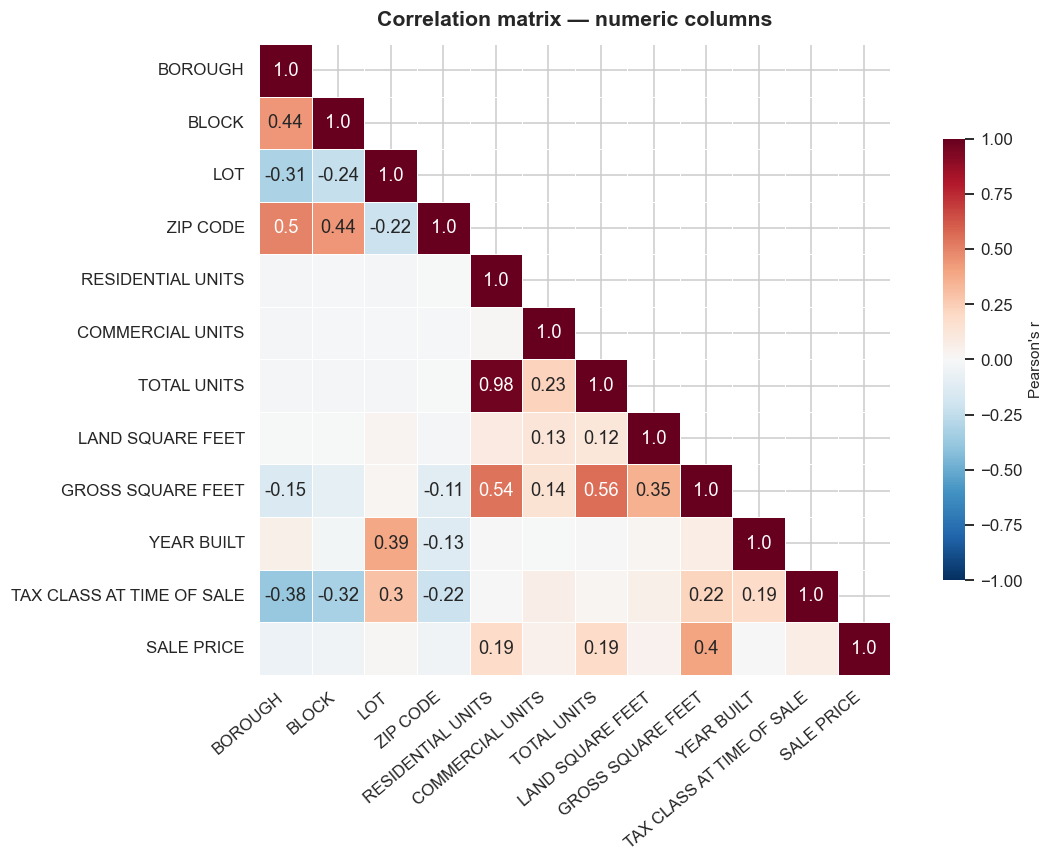

In [31]:
numeric_df = data.select_dtypes(include=np.number).drop(columns=['is_arms_length'], errors='ignore')
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
annot = corr.round(2).astype(str)
annot = annot.where(corr.abs() >= 0.1, '')

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr, mask=mask, annot=annot, fmt='', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.4,
    cbar_kws={'shrink': 0.7, 'label': "Pearson's r"}, ax=ax,
)
ax.set_title('Correlation matrix — numeric columns', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### 2.10 Summary narrative — key observations from EDA

1. **$0 sales are common and meaningful.** ~29% of records (≈591k rows) carry `SALE PRICE = 0`. These are non-cash transfers of ownership (e.g. parent → child), not data errors. They are retained and flagged via `is_arms_length`, so downstream price analyses can filter while the full dataset stays available for transfer-pattern analysis.
2. **Heavy right-skew in price and area.** `SALE PRICE`, `GROSS SQUARE FEET`, and `LAND SQUARE FEET` are extremely right-skewed (skewness ≫ 1). Linear regression in Q5 must use **log transforms** on these variables.
3. **Sentinel zeros required cleaning.** `YEAR BUILT` had ~172k rows valued `0` and `LAND/GROSS SQUARE FEET` had ~645k zeros — physically impossible — coerced to `NaN` in §2.7.
4. **Long tail in categorical dimensions.** `BUILDING CLASS CATEGORY` has 146 levels and `NEIGHBORHOOD` has 517. The top 10–20 levels dominate row counts, so cross-tabs (Q3) should bucket the long tail to stay readable.
5. **Borough volume is imbalanced.** Queens (Borough 4) accounts for the largest share of transactions (~616k), followed by Brooklyn, Manhattan, Bronx, Staten Island. Borough comparisons should report medians/rates rather than absolute totals to avoid being driven by volume alone.